In [3]:
import pandas as pd
import fireducks.pandas as pd
import numpy as np
from IPython.display import SVG, display
import pandas as pd
import networkx as nx
import matplotlib.pyplot as pp


In [4]:
def make_timeseries(start="2000-01-01", end="2000-03-31", freq="1D", seed=None):
    index = pd.date_range(start=start, end=end, freq=freq, name="timestamp")
    n = len(index)
    state = np.random.RandomState(seed)
    columns = {
        "name": state.choice(["Alicia", "Liliam", "Cleverson","Julia","Pedro","Jake"], size=n),
        "id": np.arange(1,n+1) ,
        "x": state.rand(n) * 2 - 1,
        "y": state.rand(n) * 2 - 1,
    }
    
    df = pd.DataFrame(columns, index=index, columns=sorted(columns))
    if df.index[-1] == end:
        df = df.iloc[:-1]
    return df

In [5]:
timeseries = [
    make_timeseries(freq="15min", seed=i).rename(columns=lambda x: f"{x}_{i}")
    for i in range(1)
]

ts_wide = pd.concat(timeseries, axis=1)
ts_wide = ts_wide.sort_values(by=['name_0','id_0','timestamp'])
#ts_wide = ts_wide.reset_index()
ts_wide.head()

,id_0,name_0,x_0,y_0
timestamp,,,,
2000-01-01 00:30:00,3,Alicia,0.731301,0.886211
2000-01-01 02:45:00,12,Alicia,0.933612,0.611009
2000-01-01 03:00:00,13,Alicia,-0.839464,0.745467
2000-01-01 04:00:00,17,Alicia,0.474595,0.935662
2000-01-01 05:15:00,22,Alicia,-0.651259,-0.440390


# Python Integration

In [6]:
import subprocess

# Definindo o caminho para o script Julia
julia_script = "demo_integracao.jl"
ts_wide.to_csv('data.csv', index=True)
# Executando o script Julia usando subprocess
try:
    subprocess.run(["julia", julia_script], check=True)
except subprocess.CalledProcessError as e:
    print(f"Ocorreu um erro ao executar o script Julia: {e}")

The latest version of Julia in the `release` channel is 1.11.5+0.x64.linux.gnu. You currently have `1.11.4+0.x64.linux.gnu` installed. Run:

  juliaup update

in your terminal shell to install Julia 1.11.5+0.x64.linux.gnu and update the `release` channel to that version.


Executando
13×5 DataFrame
 Row │ timestamp            id_0   name_0    x_0        y_0
     │ String31             Int64  String15  Float64    Float64
─────┼────────────────────────────────────────────────────────────
   1 │ 2000-01-01 00:30:00      3  Alicia     0.731301   0.886211
   2 │ 2000-01-01 02:45:00     12  Alicia     0.933612   0.611009
   3 │ 2000-01-01 03:00:00     13  Alicia    -0.839464   0.745467
   4 │ 2000-01-01 04:00:00     17  Alicia     0.474595   0.935662
   5 │ 2000-01-01 05:15:00     22  Alicia    -0.651259  -0.44039
   6 │ 2000-01-01 06:15:00     26  Alicia    -0.395175   0.66282
   7 │ 2000-01-01 07:00:00     29  Alicia    -0.25959   -0.721666
   8 │ 2000-01-01 07:45:00     32  Alicia    -0.515243   0.760035
   9 │ 2000-01-01 09:15:00     38  Alicia     0.937536   0.4405
  10 │ 2000-01-01 10:15:00     42  Alicia    -0.611895  -0.542293
  11 │ 2000-01-01 12:15:00     50  Alicia     0.150647   0.636694
  12 │ 2000-01-01 12:30:00     51  Alicia    -0.779723   0.33

In [7]:
from sqlalchemy import create_engine

# Criar uma conexão com o banco de dados (exemplo: SQLite)
# Para outros bancos de dados, ajuste a string de conexão
engine = create_engine('sqlite:///data_SQL.db')

# 3. Escrever o DataFrame no banco de dados
ts_wide.to_sql('Tabela_TESTE', con=engine, if_exists='replace', index=True)

print("Dados gravados no banco de dados com sucesso!")
# Definindo o caminho para o script Julia
julia_script = "demo_integracao_SQL.jl"
# Executando o script Julia usando subprocess
try:
    subprocess.run(["julia", julia_script], check=True)
except subprocess.CalledProcessError as e:
    print(f"Ocorreu um erro ao executar o script Julia: {e}")

Dados gravados no banco de dados com sucesso!


The latest version of Julia in the `release` channel is 1.11.5+0.x64.linux.gnu. You currently have `1.11.4+0.x64.linux.gnu` installed. Run:

  juliaup update

in your terminal shell to install Julia 1.11.5+0.x64.linux.gnu and update the `release` channel to that version.


DF - SQL
13×5 DataFrame
 Row │ timestamp                   id_0   name_0  x_0        y_0
     │ String                      Int64  String  Float64    Float64
─────┼─────────────────────────────────────────────────────────────────
   1 │ 2000-01-01 00:30:00.000000      3  Alicia   0.731301   0.886211
   2 │ 2000-01-01 02:45:00.000000     12  Alicia   0.933612   0.611009
   3 │ 2000-01-01 03:00:00.000000     13  Alicia  -0.839464   0.745467
   4 │ 2000-01-01 04:00:00.000000     17  Alicia   0.474595   0.935662
   5 │ 2000-01-01 05:15:00.000000     22  Alicia  -0.651259  -0.44039
   6 │ 2000-01-01 06:15:00.000000     26  Alicia  -0.395175   0.66282
   7 │ 2000-01-01 07:00:00.000000     29  Alicia  -0.25959   -0.721666
   8 │ 2000-01-01 07:45:00.000000     32  Alicia  -0.515243   0.760035
   9 │ 2000-01-01 09:15:00.000000     38  Alicia   0.937536   0.4405
  10 │ 2000-01-01 10:15:00.000000     42  Alicia  -0.611895  -0.542293
  11 │ 2000-01-01 12:15:00.000000     50  Alicia   0.150647   0.

# Algebra Linear

In [8]:
# Definindo o caminho para o script Julia
julia_script = "algebra_linear.jl"
# Executando o script Julia usando subprocess
try:
    subprocess.run(["julia", julia_script], check=True)
except subprocess.CalledProcessError as e:
    print(f"Ocorreu um erro ao executar o script Julia: {e}")

The latest version of Julia in the `release` channel is 1.11.5+0.x64.linux.gnu. You currently have `1.11.4+0.x64.linux.gnu` installed. Run:

  juliaup update

in your terminal shell to install Julia 1.11.5+0.x64.linux.gnu and update the `release` channel to that version.
[ Info: Using cofactor expansion to calculate determinant; may be very slow.


A matriz de Produção Total M é:
┌─────────┬──────────┬──────────┬──────────┐
│ Produto │ Semana 1 │ Semana 2 │ Semana 3 │
├─────────┼──────────┼──────────┼──────────┤
│       A │       16 │        9 │        1 │
│       B │        0 │        9 │        4 │
│       C │        7 │        3 │        1 │
└─────────┴──────────┴──────────┴──────────┘
A Matriz de Receitas é:
┌─────────┬────────────────────┐
│ Produto │ Preço dos produtos │
├─────────┼────────────────────┤
│       A │                  3 │
│       B │                  9 │
│       C │                  8 │
└─────────┴────────────────────┘
A Matriz de Lucro é:
┌─────────┬───────────────────┐
│ Produto │ Lucro por Produto │
├─────────┼───────────────────┤
│       A │               137 │
│       B │               113 │
│       C │                56 │
└─────────┴───────────────────┘
--------------------------------------------------
A inversa de M é:
┌────────────┬────────────┬───────────┐
│        x'1 │        x'2 │       x'3 │
├───

# Grafos

The latest version of Julia in the `release` channel is 1.11.5+0.x64.linux.gnu. You currently have `1.11.4+0.x64.linux.gnu` installed. Run:

  juliaup update

in your terminal shell to install Julia 1.11.5+0.x64.linux.gnu and update the `release` channel to that version.


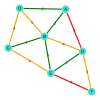

In [9]:
# Definindo o caminho para o script Julia
julia_script = "demo_graph.jl"
# Executando o script Julia usando subprocess
try:
    subprocess.run(["julia", julia_script], check=True)
except subprocess.CalledProcessError as e:
    print(f"Ocorreu um erro ao executar o script Julia: {e}")

display(SVG("graph_SeervadaPark.svg"))
